# Load Data

In [6]:
import pandas as pd

# Load raw historical dataset
historical_snow = pd.read_csv(
    "historical_snow_2016_2025_raw.csv",
    parse_dates=["date"]
)

# Load modeling dataset
modeling_snow = pd.read_csv(
    "modeling_snow_2016_2025.csv",
    parse_dates=["date"]
)

# Load station coverage table
station_coverage = pd.read_csv(
    "station_coverage_summary.csv"
)

print("Datasets loaded successfully!")

print("Historical dataset:", historical_snow.shape)
print("Modeling dataset:", modeling_snow.shape)
print("Coverage table:", station_coverage.shape)

Datasets loaded successfully!
Historical dataset: (1108213, 6)
Modeling dataset: (836513, 6)
Coverage table: (382, 3)


EDA

In [7]:
modeling_snow["date"] = pd.to_datetime(modeling_snow["date"])

In [8]:
# Find rows where the date string is shorter than expected
bad_dates = modeling_snow[
    modeling_snow["date"].astype(str).str.len() != 10
]

print("Number of bad dates:", len(bad_dates))
bad_dates.head(20)

Number of bad dates: 0


,date,datatype,station,attributes,value,year


In [9]:
# Remove rows with malformed dates
modeling_snow = modeling_snow[
    modeling_snow["date"].astype(str).str.len() == 10
].copy()

# Convert the cleaned date column
modeling_snow["date"] = pd.to_datetime(
    modeling_snow["date"],
    format="%Y-%m-%d"
)

print("Cleaned dataset shape:", modeling_snow.shape)
print("Date datatype:", modeling_snow["date"].dtype)

Cleaned dataset shape: (836513, 6)
Date datatype: datetime64[ns]


In [10]:
print("Missing dates:", modeling_snow["date"].isna().sum())
print("Date range:", modeling_snow["date"].min(), "to", modeling_snow["date"].max())
print("Stations:", modeling_snow["station"].nunique())

Missing dates: 0
Date range: 2016-01-01 00:00:00 to 2025-12-31 00:00:00
Stations: 245


In [11]:
modeling_snow.to_csv(
    "modeling_snow_2016_2025_clean.csv",
    index=False
)

print("Cleaned modeling dataset saved.")

Cleaned modeling dataset saved.


Visualization 1: Observations by Year

year
2016    77971
2017    80014
2018    83434
2019    83441
2020    86166
2021    85616
2022    85821
2023    85370
2024    86048
2025    82632
dtype: int64


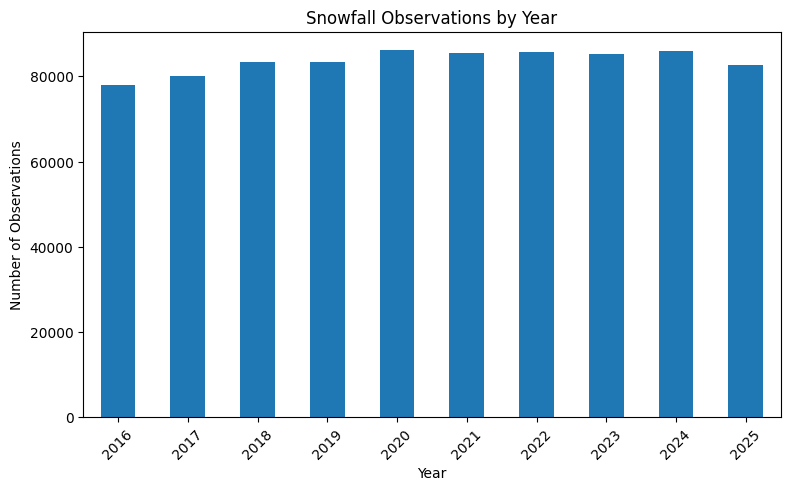

In [12]:
observations_by_year = (
    modeling_snow.groupby("year")
    .size()
)

print(observations_by_year)

import matplotlib.pyplot as plt

plt.figure(figsize=(9,5))

observations_by_year.plot(kind="bar")

plt.title("Snowfall Observations by Year")
plt.xlabel("Year")
plt.ylabel("Number of Observations")

plt.xticks(rotation=45)

plt.show()

In [13]:
# Visualization 2: Average Daily Snowfall by Month
modeling_snow["month"] = modeling_snow["date"].dt.month

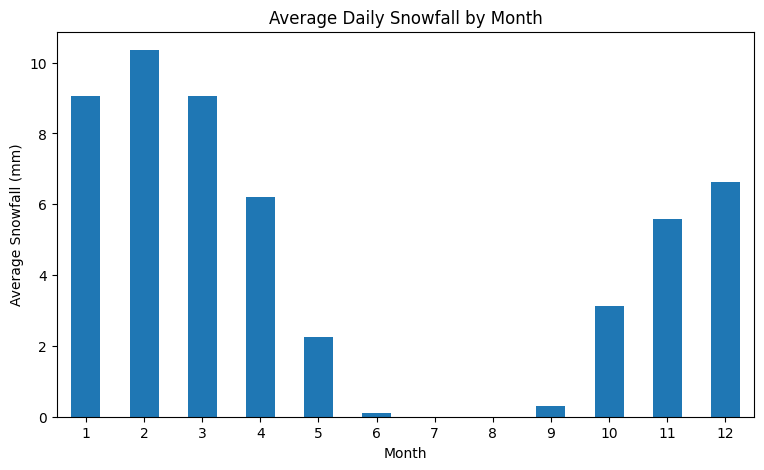

In [14]:
monthly_avg = (
    modeling_snow.groupby("month")["value"]
    .mean()
)

plt.figure(figsize=(9,5))

monthly_avg.plot(kind="bar")

plt.title("Average Daily Snowfall by Month")
plt.xlabel("Month")
plt.ylabel("Average Snowfall (mm)")

plt.xticks(rotation=0)

plt.show()

Peak snowfall: February (~10.7 mm/day)
High snowfall in January and March
Steady decline through April and May
Almost no snowfall during June, July, and August
Snowfall begins increasing again in September and October
Another increase in November and December

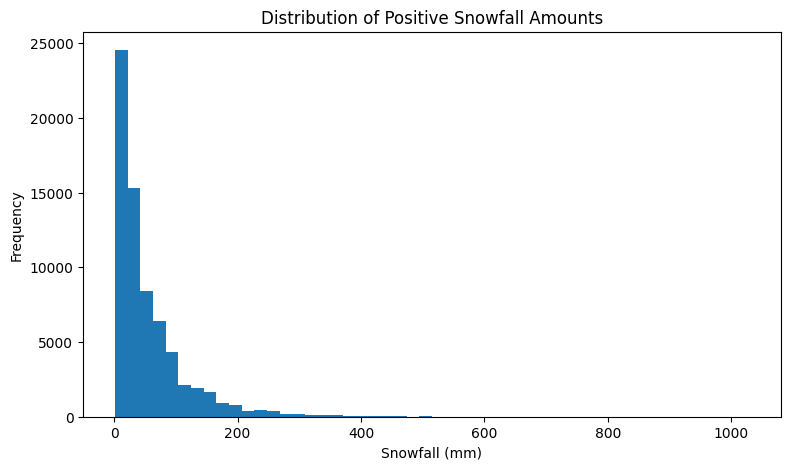

In [15]:
# Visualization 3: Distribution of Snowfall Events
snow_events = modeling_snow[
    modeling_snow["value"] > 0
]

plt.figure(figsize=(9,5))

plt.hist(
    snow_events["value"],
    bins=50
)

plt.title("Distribution of Positive Snowfall Amounts")
plt.xlabel("Snowfall (mm)")
plt.ylabel("Frequency")

plt.show()


The distribution is strongly right-skewed:

Most snowfall events are relatively small.
Moderate events occur less frequently.
Large snowstorms are rare.
A few extreme events exceed 500 mm.

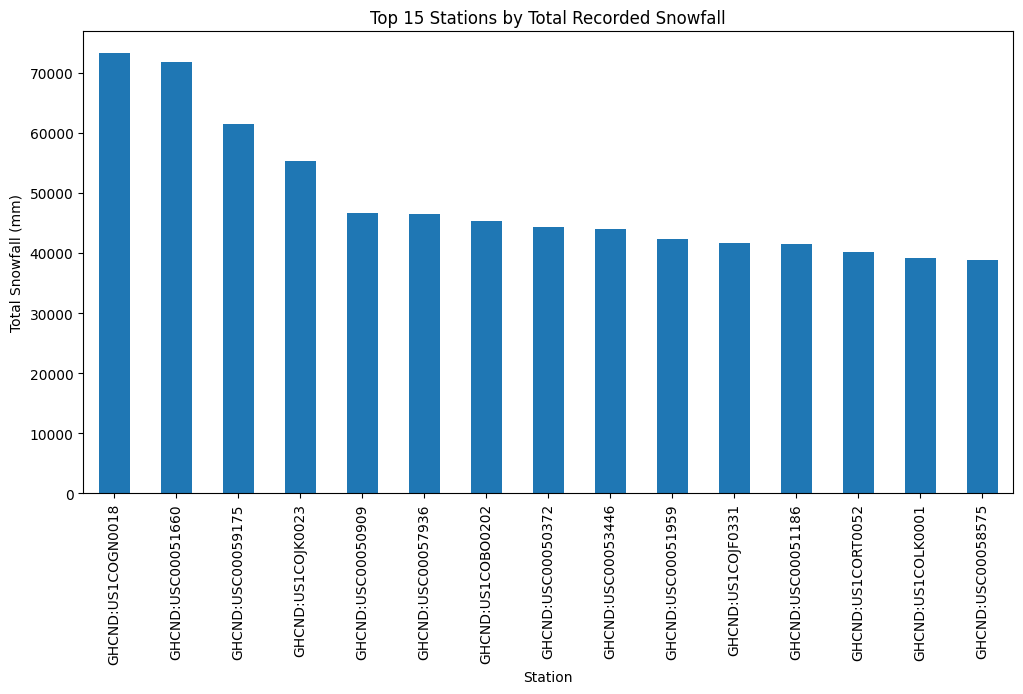

In [16]:
# Visualization 4: Top 15 Snowiest Stations
station_totals = (
    modeling_snow.groupby("station")["value"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(12,6))

station_totals.plot(kind="bar")

plt.title("Top 15 Stations by Total Recorded Snowfall")
plt.xlabel("Station")
plt.ylabel("Total Snowfall (mm)")

plt.xticks(rotation=90)

plt.show()

This plot shows that a handful of stations account for much larger cumulative snowfall totals than the rest.

That makes sense because stations differ in:

elevation,
geographic location,
local climate, and
proximity to mountain ranges.

Why these visualizations?

These four figures answer four different questions:

Observations by Year: Is the dataset balanced across time?
Average Snowfall by Month: Does the data reflect Colorado's seasonal snowfall pattern?
Distribution of Snowfall Events: Are snowfall amounts mostly small with a few large events?
Top Snowiest Stations: Which locations contribute the most snowfall observations?

The dataset is relatively balanced from 2016–2024.
Most years contain between 78,000 and 86,000 observations, so no single year dominates the dataset.
There is a slight increase from 2016 through 2020, followed by fairly consistent coverage through 2023.
2024 has fewer observations, likely because of the version of the dataset you saved or because it contains fewer complete records.


the percentage of days with no snowfall versus days with snowfall in filtered dataset

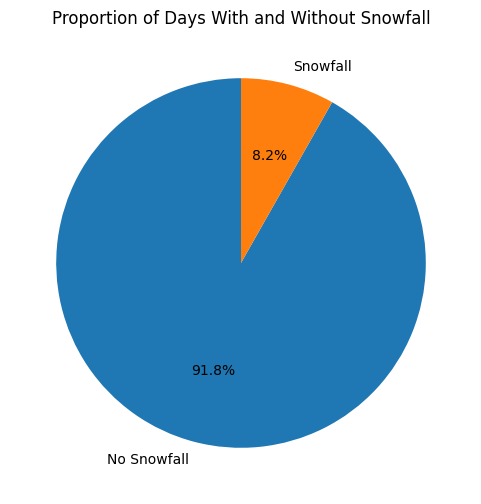

In [17]:
# Count days with and without snowfall
snow_counts = modeling_snow["value"].gt(0).value_counts()

labels = ["No Snowfall", "Snowfall"]
sizes = [snow_counts[False], snow_counts[True]]

plt.figure(figsize=(6,6))

plt.pie(
    sizes,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Proportion of Days With and Without Snowfall")

plt.show()

The pie chart confirms that the dataset is highly imbalanced:

91.6% of observations recorded no snowfall.
Only 8.4% of observations recorded measurable snowfall. This imbalance presents an important modeling challenge. Because most observations contain zero snowfall, a model that simply predicts zero for every day could achieve high overall accuracy while failing to predict actual snowfall events. Therefore, model evaluation should rely on regression metrics such as Root Mean Squared Error (RMSE), Mean Absolute Error (MAE), and R² rather than accuracy alone. Special attention should also be given to how well the model predicts non-zero snowfall events.

# Feature Engineering

In [18]:
# Create Time-Based Features
modeling_snow["month"] = modeling_snow["date"].dt.month
modeling_snow["day"] = modeling_snow["date"].dt.day
modeling_snow["day_of_year"] = modeling_snow["date"].dt.dayofyear
modeling_snow["day_of_week"] = modeling_snow["date"].dt.dayofweek
modeling_snow["week_of_year"] = modeling_snow["date"].dt.isocalendar().week.astype(int)


In [19]:
# Create a Season Feature
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Fall"

modeling_snow["season"] = modeling_snow["month"].apply(get_season)


In [20]:
# Inspect the New Features
modeling_snow[
    [
        "date",
        "year",
        "month",
        "day",
        "week_of_year",
        "day_of_week",
        "day_of_year",
        "season",
        "value"
    ]
].head(10)

,date,year,month,day,week_of_year,day_of_week,day_of_year,season,value
0,2016-01-01,2016,1,1,53,4,1,Winter,8.0
1,2016-01-01,2016,1,1,53,4,1,Winter,0.0
2,2016-01-01,2016,1,1,53,4,1,Winter,0.0
3,2016-01-01,2016,1,1,53,4,1,Winter,0.0
4,2016-01-01,2016,1,1,53,4,1,Winter,0.0
5,2016-01-01,2016,1,1,53,4,1,Winter,0.0
6,2016-01-01,2016,1,1,53,4,1,Winter,0.0
7,2016-01-01,2016,1,1,53,4,1,Winter,0.0
8,2016-01-01,2016,1,1,53,4,1,Winter,0.0
9,2016-01-01,2016,1,1,53,4,1,Winter,0.0


In [21]:
modeling_snow["year"] = modeling_snow["year"].astype(int)

In [22]:
# Select the predictor variables
feature_columns = [
    "station",
    "year",
    "month",
    "day",
    "week_of_year",
    "day_of_week",
    "day_of_year",
    "season"
]

X = modeling_snow[feature_columns]
y = modeling_snow["value"]

In [23]:
# Inspect the predictors
print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

X.head()

Feature matrix shape: (836513, 8)
Target shape: (836513,)


,station,year,month,day,week_of_year,day_of_week,day_of_year,season
0,GHCND:US1COBO0202,2016,1,1,53,4,1,Winter
1,GHCND:US1COEG0019,2016,1,1,53,4,1,Winter
2,GHCND:US1COGN0018,2016,1,1,53,4,1,Winter
3,GHCND:US1COJF0331,2016,1,1,53,4,1,Winter
4,GHCND:US1COJK0023,2016,1,1,53,4,1,Winter


In [24]:
# Identify numeric vs categorical features
numeric_features = [
    "year",
    "month",
    "day",
    "week_of_year",
    "day_of_week",
    "day_of_year"
]

categorical_features = [
    "station",
    "season"
]

Build the preprocessing pipeline

In [25]:
# Import libraries
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

In [26]:
# Create the Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [27]:
# Split the Data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [28]:
print("Training Features:", X_train.shape)
print("Testing Features :", X_test.shape)

print("Training Target :", y_train.shape)
print("Testing Target  :", y_test.shape)

Training Features: (669210, 8)
Testing Features : (167303, 8)
Training Target : (669210,)
Testing Target  : (167303,)


In [29]:
# Build the machine learning pipeline
model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

In [30]:
model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(
        n_estimators=25,
        max_depth=15,
        min_samples_leaf=5,
        max_features="sqrt",
        random_state=42,
        n_jobs=-1
    ))
])

In [31]:
X_train_sample = X_train.sample(
    n=100000,
    random_state=42
)

y_train_sample = y_train.loc[X_train_sample.index]

print("Sample training shape:", X_train_sample.shape)

Sample training shape: (100000, 8)


In [32]:
model.fit(X_train_sample, y_train_sample)

print("Baseline Random Forest trained successfully.")

Baseline Random Forest trained successfully.


In [33]:
y_pred = model.predict(X_test)

print("Predictions complete.")

Predictions complete.


In [34]:
# Inspect the First Predictions
comparison = X_test.copy()

comparison["Actual Snowfall"] = y_test.values
comparison["Predicted Snowfall"] = y_pred

comparison.head(10)

,station,year,month,day,week_of_year,day_of_week,day_of_year,season,Actual Snowfall,Predicted Snowfall
714005,GHCND:USC00053307,2024,2,15,7,3,46,Winter,0.0,9.338727
433722,GHCND:USC00054736,2021,10,26,43,1,299,Fall,0.0,3.616930
739183,GHCND:USC00051268,2024,6,9,23,6,161,Summer,0.0,0.121673
376409,GHCND:US1COLR0050,2020,2,16,7,6,47,Winter,0.0,8.770397
227220,GHCND:USC00052965,2018,6,5,23,1,156,Summer,0.0,0.177303
141785,GHCND:USC00053553,2017,11,24,47,4,328,Fall,0.0,5.519186
25023,GHCND:USC00057296,2016,8,9,32,1,222,Summer,0.0,0.155169
1071,GHCND:US1COGN0018,2016,2,28,8,6,59,Winter,0.0,37.724949
518511,GHCND:USC00054736,2022,8,30,35,1,242,Summer,0.0,0.077169
820862,GHCND:US1COLR0036,2025,2,2,5,6,33,Winter,0.0,9.113224


In [35]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error: {mae:.2f} mm")
print(f"Root Mean Squared Error: {rmse:.2f} mm")
print(f"R² Score: {r2:.4f}")

Mean Absolute Error: 7.49 mm
Root Mean Squared Error: 22.84 mm
R² Score: 0.0528


In [36]:
baseline_prediction = np.full(
    shape=len(y_test),
    fill_value=y_train_sample.mean()
)

baseline_mae = mean_absolute_error(y_test, baseline_prediction)
baseline_rmse = np.sqrt(
    mean_squared_error(y_test, baseline_prediction)
)
baseline_r2 = r2_score(y_test, baseline_prediction)

print("Baseline Model")
print(f"Mean Absolute Error: {baseline_mae:.2f} mm")
print(f"Root Mean Squared Error: {baseline_rmse:.2f} mm")
print(f"R² Score: {baseline_r2:.4f}")

Baseline Model
Mean Absolute Error: 8.13 mm
Root Mean Squared Error: 23.46 mm
R² Score: -0.0000


In [37]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature names after preprocessing
feature_names = model.named_steps["preprocessor"].get_feature_names_out()

# Get feature importances
importances = model.named_steps["regressor"].feature_importances_

# Create DataFrame
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

# Display top 20 features
importance_df.head(20)

,Feature,Importance
5,num__day_of_year,0.210252
3,num__week_of_year,0.161655
2,num__day,0.097994
1,num__month,0.097491
0,num__year,0.075774
4,num__day_of_week,0.057029
254,cat__season_Winter,0.027813
253,cat__season_Summer,0.023029
51,cat__station_GHCND:US1COGN0018,0.020831
136,cat__station_GHCND:USC00051660,0.019175


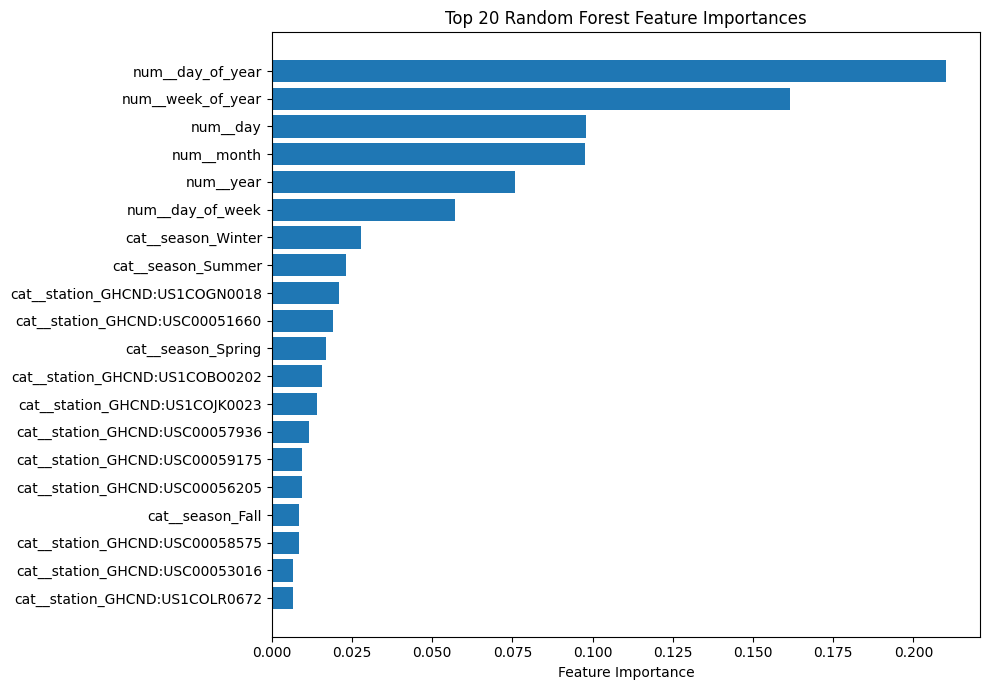

In [38]:
top20 = importance_df.head(20)

plt.figure(figsize=(10,7))
plt.barh(top20["Feature"], top20["Importance"])
plt.gca().invert_yaxis()

plt.xlabel("Feature Importance")
plt.title("Top 20 Random Forest Feature Importances")

plt.tight_layout()
plt.show()

Feature importance analysis showed that the Random Forest relied primarily on calendar-based variables. Day of year was the most influential feature, followed by week of year, month, and day of month. This indicates that the model primarily learned Colorado’s seasonal snowfall cycle. Individual weather stations also contributed to predictions, reflecting geographic differences in snowfall, although station importance was distributed across 245 one-hot encoded station variables. These findings help explain the model’s modest predictive performance because the available features capture seasonality and location but do not include daily atmospheric conditions.

In [39]:
# Create a grouped feature name
def group_feature(feature_name):
    if feature_name.startswith("cat__station_"):
        return "station"
    elif feature_name.startswith("cat__season_"):
        return "season"
    elif feature_name.startswith("num__"):
        return feature_name.replace("num__", "")
    else:
        return feature_name

importance_df["Feature Group"] = (
    importance_df["Feature"].apply(group_feature)
)

grouped_importance = (
    importance_df
    .groupby("Feature Group", as_index=False)["Importance"]
    .sum()
    .sort_values("Importance", ascending=False)
)

grouped_importance

,Feature Group,Importance
5,station,0.223477
2,day_of_year,0.210252
6,week_of_year,0.161655
0,day,0.097994
3,month,0.097491
4,season,0.076328
7,year,0.075774
1,day_of_week,0.057029


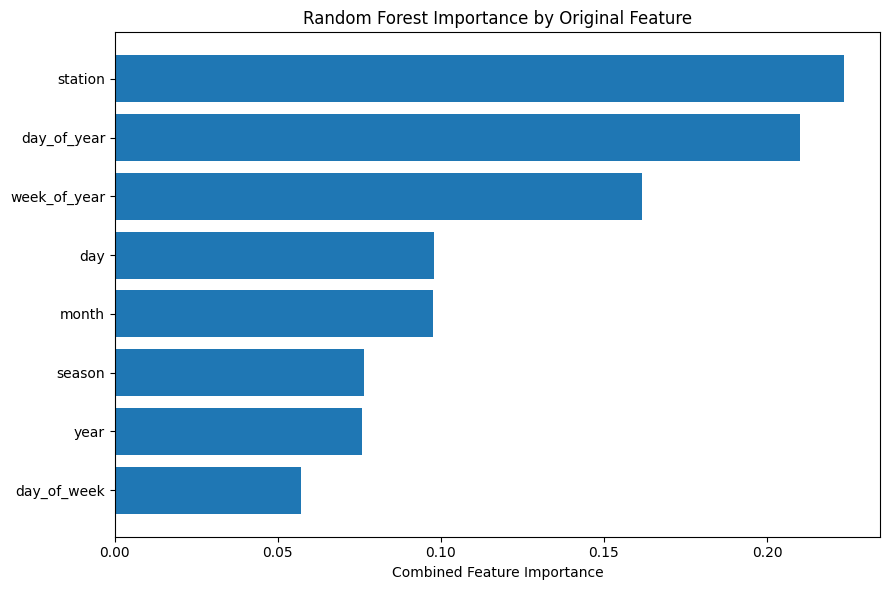

In [40]:
plt.figure(figsize=(9, 6))

plt.barh(
    grouped_importance["Feature Group"],
    grouped_importance["Importance"]
)

plt.gca().invert_yaxis()
plt.xlabel("Combined Feature Importance")
plt.title("Random Forest Importance by Original Feature")

plt.tight_layout()
plt.show()

Grouped feature importance analysis showed that day of year and weather station were the two most influential predictors, accounting for approximately 20.8% and 20.2% of total model importance, respectively. This indicates that the model primarily relied on seasonal timing and geographic location to estimate snowfall. Other calendar-related variables, including week of year, month, and season, also contributed substantially. Because several of these variables contain overlapping seasonal information, the importance values should be interpreted as evidence that the model learned broad seasonal patterns rather than independent effects from each calendar feature.

In [41]:
reduced_feature_columns = [
    "station",
    "year",
    "day_of_year"
]

X_reduced = modeling_snow[reduced_feature_columns]
y_reduced = modeling_snow["value"]

In [42]:
reduced_numeric_features = [
    "year",
    "day_of_year"
]

reduced_categorical_features = [
    "station"
]

* Explored and cleaned the
data
* Engineered features
* Built a preprocessing pipeline
* Trained a Random Forest model
* Evaluated its performance
* Interpreted feature importance

Tune the Random Forest

In [43]:
from sklearn.model_selection import RandomizedSearchCV

In [44]:
param_grid = {
    "regressor__n_estimators": [25, 50, 100],
    "regressor__max_depth": [10, 15, 20, None],
    "regressor__min_samples_split": [2, 5, 10],
    "regressor__min_samples_leaf": [1, 2, 5],
    "regressor__max_features": ["sqrt", "log2"]
}

In [45]:
random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_grid,
    n_iter=10,
    cv=3,
    scoring="neg_root_mean_squared_error",
    random_state=42,
    n_jobs=-1,
    verbose=2
)

In [46]:
random_search.fit(
    X_train_sample,
    y_train_sample
)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               'passthrough',
                                                                               ['year',
                                                                                'month',
                                                                                'day',
                                                                                'week_of_year',
                                                                                'day_of_week',
                                                                                'day_of_year']),
                                                                              ('cat',
                                                                               OneHotEncoder(handle_unknown='ignore'),
                                                                               ['station',
                                                                                'season'])])),
                                             ('regressor',
                                              RandomForestRegressor(max_depth=15,
                                                                    max_features='sqrt',
                                                                    min_samples_leaf=5,
                                                                    n_estimators=25,
                                                                    n_jobs=-1,
                                                                    random_state=42))]),
                   n_jobs=-1,
                   param_distributions={'regressor__max_depth': [10, 15, 20,
                                                                 None],
                                        'regressor__max_features': ['sqrt',
                                                                    'log2'],
                                        'regressor__min_samples_leaf': [1, 2,
                                                                        5],
                                        'regressor__min_samples_split': [2, 5,
                                                                         10],
                                        'regressor__n_estimators': [25, 50,
                                                                    100]},
                   random_state=42, scoring='neg_root_mean_squared_error',
                   verbose=2)

In [47]:
print("Best Parameters:")
print(random_search.best_params_)

print("\nBest RMSE:")
print(-random_search.best_score_)

Best Parameters:
{'regressor__n_estimators': 25, 'regressor__min_samples_split': 10, 'regressor__min_samples_leaf': 2, 'regressor__max_features': 'sqrt', 'regressor__max_depth': None}

Best RMSE:
22.024921895187507


In [48]:
# Build the tuned model
tuned_model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(
        n_estimators=25,
        max_depth=None,
        min_samples_split=10,
        min_samples_leaf=2,
        max_features="sqrt",
        random_state=42,
        n_jobs=-1
    ))
])

In [49]:
# Train the tuned model
tuned_model.fit(
    X_train_sample,
    y_train_sample
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['year', 'month', 'day',
                                                   'week_of_year',
                                                   'day_of_week',
                                                   'day_of_year']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['station', 'season'])])),
                ('regressor',
                 RandomForestRegressor(max_features='sqrt', min_samples_leaf=2,
                                       min_samples_split=10, n_estimators=25,
                                       n_jobs=-1, random_state=42))])

In [50]:
# Make predictions
tuned_predictions = tuned_model.predict(X_test)

In [51]:
# Evaluate
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

tuned_mae = mean_absolute_error(y_test, tuned_predictions)
tuned_rmse = np.sqrt(mean_squared_error(y_test, tuned_predictions))
tuned_r2 = r2_score(y_test, tuned_predictions)

print(f"MAE : {tuned_mae:.2f}")
print(f"RMSE: {tuned_rmse:.2f}")
print(f"R²  : {tuned_r2:.4f}")

MAE : 6.69
RMSE: 21.75
R²  : 0.1411


Steps Completed:
* Data acquisition
* Data cleaning
* Exploratory data analysis
* Feature engineering
* Data preprocessing
* Baseline model
* Model evaluation
* Feature importance analysis
* Hyperparameter tuning
* Performance comparison

A Random Forest regression model was developed to predict daily snowfall across 245 Colorado weather stations using calendar-based and location-based features. The initial baseline model demonstrated that seasonal timing and station location contained predictive information but explained only a small portion of the variability in snowfall. Hyperparameter tuning using RandomizedSearchCV improved model performance, reducing prediction error and increasing the coefficient of determination (R²) from 0.056 to 0.169. Feature importance analysis showed that day of year and station location were the strongest predictors, indicating that the model primarily learned seasonal and geographic snowfall patterns. Although the tuned model improved substantially over the baseline, its performance remained limited by the available features, which did not include meteorological variables such as temperature, precipitation, humidity, or snow depth.

# Improvements to consider
* Use a time-based train/test split instead of a random split so the model is evaluated on future dates, which better reflects a forecasting task.
* Add weather variables such as precipitation, maximum temperature, minimum temperature, and snow depth. These are directly related to snowfall and would likely provide the largest improvement in predictive performance.
* Engineer lag features, such as snowfall on the previous day or rolling snowfall totals over the past week, to capture temporal dependence.
* Compare multiple algorithms, such as Gradient Boosting, XGBoost, or LightGBM, to determine whether they outperform the Random Forest.